# PyTorch Workflow
Let's explore an example PyTorch end-to-end workflow.

Resources:
* Ground-truth notebook – https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb
* Book version – https://www.learnpytorch.io/01_pytorch_workflow/
* Discussions – https://github.com/mrdbourke/pytorch-deep-learning/discussions

Our Workflow:
1. Data (loading and preparing)
2. Build a model
3. Fitting the model to data (training)
4. Making predictions and evaluating a model (inference)
5. Saving and loading a model
6. Putting all of it together
## Importing required modules

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
# Check pytorch version
print(torch.__version__)

2.12.0+cu130


## Data Preparing and Loading
Data can be anything... in Machine Learning.
You can have:
* Images of any king
* Text
* Excel Spreadsheet or Tabular Data
* Audio like podcasts, songs
* Videos
* DNA

Machine Learning is a game of two parts:
1. Getting data into a numerical representation.
2. Building a model to learn patterns in that numerical representation.

To showcase this, let's create some _known_ data using the Linear Regression formula.
We'll use a linear regression formula to make a straight line with _known_ **parameters**.
### Creating some data


In [2]:
# Create _known_ parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10],

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

### Splitting Data into Training and Test sets
This is one of the most **important** concepts in Machine Learning.
We **split** the data into:
1. Training set:
Our model learns from this dataset. _Think of it as the study materials._ Around **60–80%** of the data. This is always used.
2. Validation set:
We tune our model using this data set. _Think of it as a Practice exam._ Around **10–20%** of the data. This is often used, but not always.
3. Test set:
We evaluate our model using this data set. _Think of it as the final exam._ Around **10–20%** of the data. This is always used.

Let's split our above data into training and testing sets.

In [4]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize the data? This is where the data-explorer's moto comes in...

**"Visualize, visualize, visualize!"**
### Plotting the Data

In [5]:
def plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None):
    """
    Plots training data, test data, and predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot the training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
    # Plot the testing data
    plt.scatter(test_data, test_labels, c='g', s=4, label="Testing Data")
    # Plot the predictions if any
    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label="Predictions")
    # Show the legends
    plt.legend(prop={'size': 14})
    # Hide the axes
    # plt.grid(False)

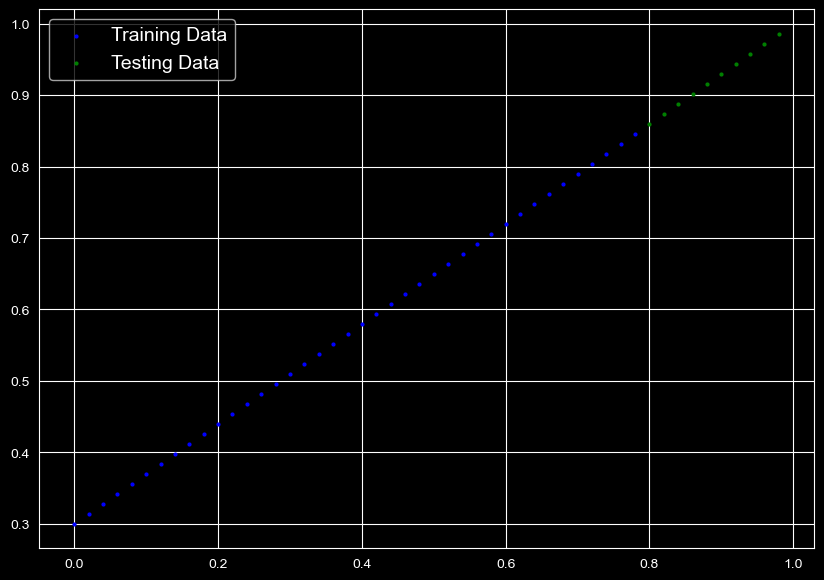

In [6]:
plot_prediction()

## Building a model
Let's build our very first PyTorch model. Because we're going to be building classes all along, refer to the following resource: https://realpython.com/python3-object-oriented-programming/

What our model does:
1. Start with random values (weight and bias).
2. Look at training data and adjust the random values to better represent (or get closer to) the ideal values of the data (weight and bias values we used to create the data).

How does it do so? Mainly, through these two algorithms:
1. Gradient descent:     https://youtu.be/IHZwWFHWa-w
2. Backpropagation:      https://youtu.be/Ilg3gGewQ5U
### Create a Model

In [7]:
# Create a Linear Regression model
class LinearRegressionModel(nn.Module): #<- Almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1,      # <-- start with a random weight and try to adjust it to the ideal weight
                                                requires_grad=True,     # <-- can this parameter be updated via gradient descent?
                                                dtype=torch.float))     # PyTorch loves the data-type torch.float32
        self.bias = nn.Parameter(torch.randn(1,         # <-- start with a random bias and try to adjust it to the ideal bias
                                            requires_grad=True,     # <-- can this parameter be updated via gradient descent?
                                             dtype=torch.float))    # <-- PyTorch loves the data-type torch.float32
    # Forward method to define the computation in the model (forward pass)
    def forward(self, x: torch.Tensor) -> torch.Tensor: # 'x' is the input data
            return self.weight * x + self.bias # <-- Linear Regression formula

### PyTorch Model Building Essentials
1. **torch.nn** – contains all the buildings for computational graphs (a neural network can be considered as a computational graph).
2. **torch.nn.Parameter** – what parameters should our models try and learn, often a PyTorch layer from torch.nn will set these for us.
3. **torech.nn.Module** – The base class for all neural network modules, if you subclass it, you should overwrite forward()
4. **torch.optim** – this is where the optimizers for in PyTorch live, they will help with gradient descent.
5. **def foward()** – All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation.
6. **torch.utils.data.DataSet** – Represents a map between key (label) and sample (features) pairs of your data. Such as images and their associated labels.
7. **torch.utils.data.DataLoader** – Creates a Python iterable over a dataset (allows you to iterate over your data).

Cheatsheet for PyTorch: https://pytorch-cn.com/tutorials/beginner/ptcheat.html

### Checking the contents of our PyTorch model
Now that we've created a model, let's see what's inside...
So we can check our model paramters or what's inside our model using `.parameters()`.

In [8]:
# Create a random seed
torch.manual_seed(42)
# Create an instance of the model (this is a subclass of nn.Module())
model_0 = LinearRegressionModel()
# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
# List named parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions using `torch.inference_mode()`
To check out our model's predictive power, let's see how well it predicts `y_test` based on `X_test`.
When we pass data through our model, it's going to run it through the forward() method.

In [10]:
# Make predictions with the model
with torch.inference_mode():    # <-- context manager to disable gradient computation
    y_test_pred = model_0(X_test)
 # Alternate to do the same thing but not advised (depreciated) is to do the following
# with torch.no_grad():
#     y_test_pred = model_0(X_test)
y_test_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [11]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

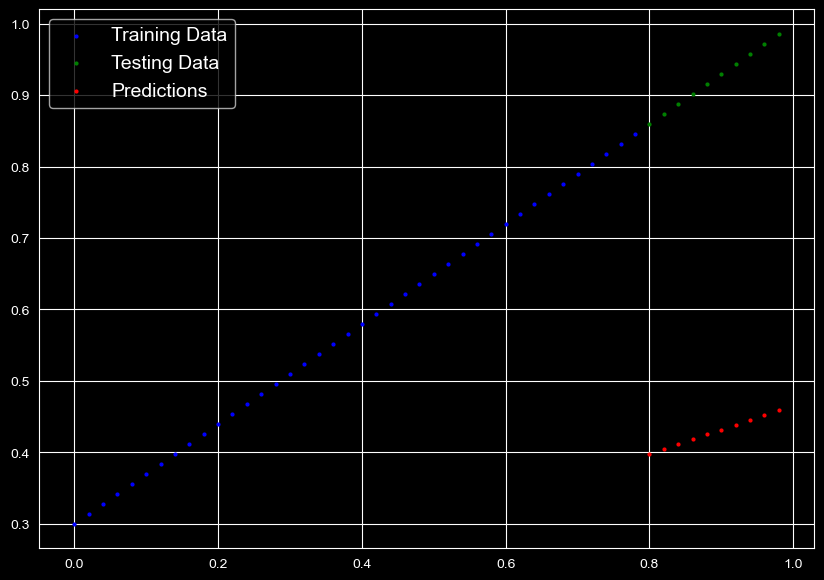

In [12]:
plot_prediction(predictions=y_test_pred)

## Training the model
The whole idea of training a model is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters. Or in some other words, from a poor representation to a better representation of the data.

One way to measure how poorly or well our model is performing is to use a loss function.

**Note**: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer it to as 'loss' function.
Things we need to train:
* **Loss function**: A function to measure how wrong our model's predictions are in comparison to the ideal outputs; the lower, the better.
* **Optimizer**: Takes into account the loss of the model and adjusts the model's parameters (e.g., weight and bias) to improve the loss function: https://docs.pytorch.org/docs/2.12/optim.html#optimizer-step
    * Inside the optimizer you'll often have to set two parameters:
        * `params` - the model you'd like to optimize, for example, `params=model_0.parameters()`
        * `lr`(learning rate) – the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step of the training loop (a small `lr` results in small changes per cycle, a large `lr` results in large changes per cycle).

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [13]:
# Check the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [14]:
# Check out our model's parameters
# A parameter is a value that our model sets itself
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [15]:
# Set up a loss function
loss_fn = nn.L1Loss()

# Set up an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),    # we want to optimize the parameters in our model
                            lr= 0.01)   # learning rate = possibly the most important hyperparameter you can set

**FAQs regarding loss function:**

**Q**: Which loss function should I use?

**A**: This will be problem-specific, but with experience, you'll get an idea of what works and what doesn't with your problem set.
For example, for a regression problem (like ours), a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` should suffice.

But for a classification problem like classifying whether a photo is of a dog or a cat, you'll likely want to use a `nn.BCELoss()` (binary cross-entropy loss).
### Building a training loop (and a testing loop) in PyTorch
A couple of things we need in PyTorch:
1. Loop through the data.
2. Forward Pass (also called **forward propagation**) – this involves data through our model's `foward()` function to make predictions.
3. Calculate the loss – compare forward pass predictions to ground truth labels.
4. Optimize zero grad
5. Loss Backward (also called **backpropagation**) – this involves calculating the gradients of the loss with respect to the model's parameters, backwards through the network.
6. Optimizer step – use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**).

In [16]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [17]:
torch.manual_seed(42)
# Epoch: An epoch is one loop/cycle through the data.
epochs = 200

# Track different values
epoch_count = []
train_loss_values = []
test_loss_values = []
### Training
# 1. Loop through the data
for epoch in range(epochs):
    # Set the model to training mode
    model_0.train() # train mode in PyTorch sets all Parameters that require gradients to require gradients

    # 2. Forward Pass
    y_train_pred = model_0(X_train)

    # 3. Calculate the loss
    loss = loss_fn(y_train_pred, y_train)

    # 4. Optimize zero grad
    optimizer.zero_grad()   # Initializes grad to zero

    # 5. Perform backpropagation on the loss function with respect to the model's parameters
    loss.backward()

    # 6. Step the optimizer (perform gradient descent)
    optimizer.step()    # By default, the optimizer will accumulate through the loop so...
    # That's why we have to zero them above in step 3 for the next iteration.

    # Testing
    model_0.eval()  # Turns off different settings in the model not required for evaluation/testing
    with torch.inference_mode():    # Turns off gradient tracking & a couple of more things behind the scenes: https://x.com/PyTorch/status/1437838236529868803
    # with torch.no_grad(): # you may also see this in older pytorch code, but it's not advised
        # 1. Do the forward pass
        y_test_pred_new = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(y_test_pred_new, y_test)

    # Print out what's happening
    if epoch % 20 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
        # Print model.state_dict()
        print(model_0.state_dict())

Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.48106518387794495
OrderedDict({'weight': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.21729660034179688
OrderedDict({'weight': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953003168106
OrderedDict({'weight': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 60 | Loss: 0.03818932920694351 | Test Loss: 0.08886633068323135
OrderedDict({'weight': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch: 80 | Loss: 0.03132382780313492 | Test Loss: 0.07232122868299484
OrderedDict({'weight': tensor([0.5459]), 'bias': tensor([0.3648])})
Epoch: 100 | Loss: 0.024458957836031914 | Test Loss: 0.05646304413676262
OrderedDict({'weight': tensor([0.5800]), 'bias': tensor([0.3503])})
Epoch: 120 | Loss: 0.01758546568453312 | Test Loss: 0.04060482233762741
OrderedDict({'weight': tensor([0.6141]), 'bias': tensor([0.3358])})
Epoch: 140 | Loss: 0.0107

In [18]:
with torch.inference_mode():
    y_test_pred_final = model_0(X_test)

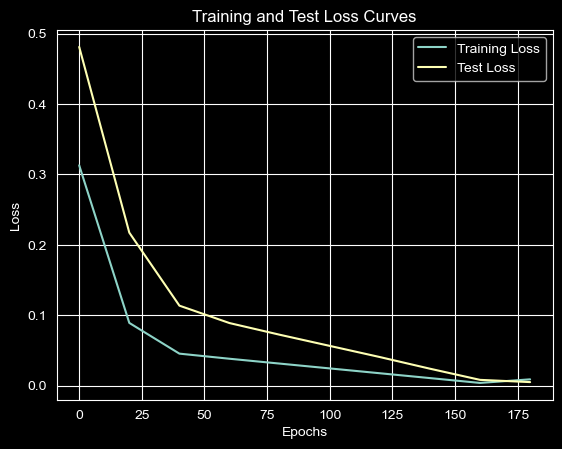

In [24]:
import numpy as np
# Plot the loss values
plt.plot(epoch_count,
         np.array(torch.tensor(train_loss_values).detach().cpu().numpy()),
         label="Training Loss"),
plt.plot(epoch_count,
         np.array(torch.tensor(test_loss_values).detach().cpu().numpy()),
         label="Test Loss"),
plt.title("Training and Test Loss Curves")
plt.xlabel("Epochs"),
plt.ylabel("Loss"),
plt.legend();

In [20]:
weight, bias

(0.7, 0.3)

In [21]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

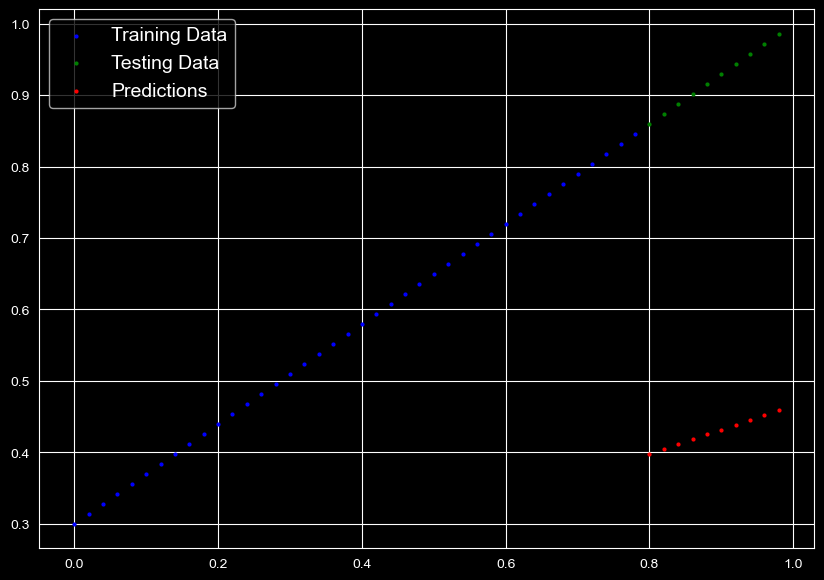

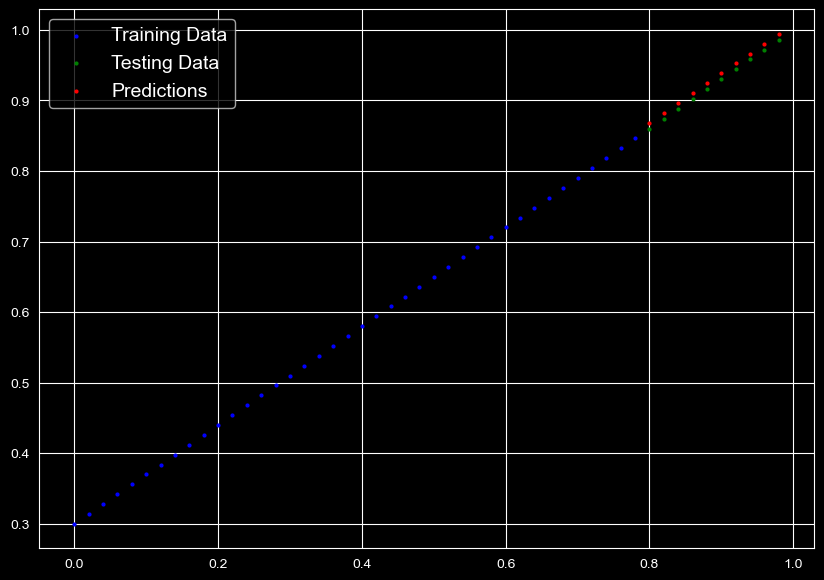

In [22]:
plot_prediction(predictions=y_test_pred),
plot_prediction(predictions=y_test_pred_final)

## Saving a model in PyTorch

There are three main methods for saving and loading models in PyTorch
1. `torch.save()` - allows you to save a PyTorch object in Python's pickle format.
2. `torch.load()` - allows you to load a saved PyTorch object from a file.
3. `torch.nn.Module.load_state_dict()` - this allows you to load a model's saved state dictionary

Pytorch save and load tutorial/documentation: https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference

In [23]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create model's directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create a model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_workflow_model_0.pt


In [27]:
%ls -l models

 Volume in drive C is OS
 Volume Serial Number is 6E47-82ED

 Directory of C:\Users\Subhodeep\PycharmProjects\MachineLearning\Pytorch_Course


 Directory of C:\Users\Subhodeep\PycharmProjects\MachineLearning\Pytorch_Course\models

23-06-2026  01:08    <DIR>          .
23-06-2026  01:15    <DIR>          ..
23-06-2026  01:10             2,117 01_pytorch_workflow_model_0.pt
               1 File(s)          2,117 bytes
               2 Dir(s)  566,899,716,096 bytes free


File Not Found


## Loading a PyTorch model
Since we saved our model's `state_dict()` rather than the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [28]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [31]:
# To load in a saved state_dict, we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.2345])), ('bias', tensor([0.2303]))])

These above values are random, load our previous model into `loaded_model_0` and check the values.

In [34]:
# Load the saved state_dict of model_0 (this will update the new instance of with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [36]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_pred = loaded_model_0(X_test)
loaded_model_pred

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [37]:
# Compare loaded model pred with original model pred
y_test_pred_final == loaded_model_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Putting it all together